In [1]:
# ============================================================
# 4 UE x (aBS, bBS, cBS, idle)  |  constraint-free (for now)
# Encoding (per UE, 2 qubits):
#   00 -> aBS, 01 -> bBS, 10 -> cBS, 11 -> idle
#
# Weight-only Grover-style (soft) preference:
#   - assign register: uniform superposition
#   - cost qubits: start at |1> (one per UE)
#   - If UE i chooses option j, apply CRY(theta_ij) on cost[i]
#     (theta_ij ∝ weight)
#   - Mark states where all cost qubits remain |1>
#   - Diffusion over assign register
#
# NOTE: X-mask duplication 제거를 위해
#       "toggle" 방식 대신 compute/uncompute를 분리했습니다.
# ============================================================

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram


# -----------------------------
# Problem size / encoding
# -----------------------------
N_UE = 4
BITS_PER_UE = 2
N_STATE = N_UE * BITS_PER_UE      # 8 assignment qubits
N_COST  = N_UE                    # 4 cost qubits

CODES = ["00", "01", "10", "11"]  # a, b, c, idle
CODE2NAME = {"00": "aBS", "01": "bBS", "10": "cBS", "11": "idle"}

In [3]:
# -----------------------------
# State preparation
# -----------------------------
def prepare_state_register(qc, assign, cost, anc_cost, superflag):
    """
    assign: uniform superposition
    cost: |1> for all UE
    anc_cost: |0>
    superflag: |-> for phase kickback
    """
    qc.reset(assign)
    qc.h(assign)

    qc.reset(cost)
    # qc.x(cost)

    qc.reset(anc_cost)
    qc.reset(superflag)

    # superflag = |-> (H on |1>)
    qc.x(superflag)
    qc.h(superflag)

    qc.barrier()  # --- INIT ---

In [4]:
# -----------------------------
# Compute / Uncompute for "UE i chose code"
#   anc_cost[0] toggles to 1 iff match (assuming anc starts at 0)
#   IMPORTANT: compute/uncompute 분리로 불필요한 X-X 제거
# -----------------------------
def compute_match_code(qc, assign, ue_idx, code_str, anc_cost):
    """
    Compute: toggle anc_cost[0] iff 2-bit choice == code_str.
    Applies X masks + MCX, but does NOT unmask here.
    """
    q0 = assign[2 * ue_idx + 0]
    q1 = assign[2 * ue_idx + 1]

    # mask: turn "match code" into "both controls=1"
    if code_str[0] == "0":
        qc.x(q0)
    if code_str[1] == "0":
        qc.x(q1)

    qc.mcx([q0, q1], anc_cost[0])  # anc toggled if match

In [5]:
def uncompute_match_code(qc, assign, ue_idx, code_str, anc_cost):
    """
    Uncompute: reverse MCX, then undo X masks.
    """
    q0 = assign[2 * ue_idx + 0]
    q1 = assign[2 * ue_idx + 1]

    qc.mcx([q0, q1], anc_cost[0])

    # unmask (reverse order is conventional)
    if code_str[1] == "0":
        qc.x(q1)
    if code_str[0] == "0":
        qc.x(q0)

In [6]:
# -----------------------------
# Objective oracle (weight only)
# -----------------------------
def oracle_objective_phase(qc, assign, cost, anc_cost, W, alpha=1.0):
    W = np.asarray(W, dtype=float)
    w_min, w_max = float(np.min(W)), float(np.max(W))
    if w_max - w_min <= 1e-12:
        qc.barrier()
        return

    for i in range(N_UE):
        for j, code in enumerate(CODES):
            w_norm = (W[i, j] - w_min) / (w_max - w_min)   # 0..1
            theta  = alpha * np.pi * w_norm                # 0..alpha*pi

            compute_match_code(qc, assign, i, code, anc_cost)
            qc.cry(theta, anc_cost[0], cost[i])
            uncompute_match_code(qc, assign, i, code, anc_cost)

    qc.barrier()  # WEIGHT_ORACLE

In [7]:
def inverse_oracle_objective_phase(qc, assign, cost, anc_cost, W, alpha=1.0):
    W = np.asarray(W, dtype=float)
    w_min, w_max = float(np.min(W)), float(np.max(W))
    if w_max - w_min <= 1e-12:
        qc.barrier()
        return

    for i in range(N_UE):
        for j, code in enumerate(CODES):
            w_norm = (W[i, j] - w_min) / (w_max - w_min)   # 0..1
            theta  = alpha * np.pi * w_norm                # 0..alpha*pi

            compute_match_code(qc, assign, i, code, anc_cost)
            qc.cry(-theta, anc_cost[0], cost[i])
            uncompute_match_code(qc, assign, i, code, anc_cost)

    qc.barrier()  # WEIGHT_ORACLE

In [8]:
# -----------------------------
# Superflag marking: cost all-ones -> phase flip via |-> kickback
# -----------------------------
def apply_superflag_mark(qc, cost, superflag):
    qc.mcx(list(cost), superflag[0], mode="noancilla")
    qc.barrier()  # --- MARK ---

In [9]:
# -----------------------------
# Full oracle: (encode weight) -> mark -> (uncompute)
# -----------------------------
def apply_oracle_weight_only(qc, assign, cost, anc_cost, superflag, W, alpha=1.0):
    oracle_objective_phase(qc, assign, cost, anc_cost, W, alpha=alpha)
    apply_superflag_mark(qc, cost, superflag)
    inverse_oracle_objective_phase(qc, assign, cost, anc_cost, W, alpha=alpha)

In [10]:
# -----------------------------
# Diffusion on assign register
# -----------------------------
def apply_diffusion(qc, qubits):
    qc.barrier()  # --- DIFFUSION_START ---

    qc.h(qubits)
    qc.x(qubits)

    qc.h(qubits[-1])
    qc.mcx(list(qubits[:-1]), qubits[-1], mode="noancilla")
    qc.h(qubits[-1])

    qc.x(qubits)
    qc.h(qubits)

    qc.barrier()  # --- DIFFUSION_END ---

In [11]:
# -----------------------------
# Decoding utilities
# -----------------------------
def decode_assignment(bitstring, n_ue=4):
    """
    Qiskit counts key is typically MSB..LSB; reverse to access c[0] first.
    assign qubits are measured into c_assign in same index order.
    """
    bits = bitstring[::-1]
    out = []
    for i in range(n_ue):
        code = bits[2 * i] + bits[2 * i + 1]  # assign[2i], assign[2i+1]
        out.append(CODE2NAME.get(code, f"UNK({code})"))
    return out



In [12]:
def score_assignment(choices, W):
    """
    Sum weights for a decoded assignment (choices list).
    """
    name2col = {"aBS": 0, "bBS": 1, "cBS": 2, "idle": 3}
    return float(sum(W[i, name2col[ch]] for i, ch in enumerate(choices)))

In [13]:
# ============================================================
# Example weights (EDIT THIS)
# W[i, :] = [aBS, bBS, cBS, idle]
# idle을 쓰지 않게 하고 싶으면 idle column에 큰 penalty를 주는 편이 안전합니다.
# ============================================================
W = np.array([
    [0.20, 0.60, 0.40, 0.01],  # UE0
    [0.70, 0.30, 0.50, 0.01],  # UE1
    [0.40, 0.80, 0.20, 0.01],  # UE2
    [0.50, 0.40, 0.60, 0.01],  # UE3
], dtype=float)

alpha = 1.0
iterations = 1
shots = 10000


In [14]:
# -----------------------------
# Build circuit
# -----------------------------
assign    = QuantumRegister(N_STATE, "assign")
cost      = QuantumRegister(N_COST,  "cost")
anc_cost  = QuantumRegister(1,       "anc_cost")
superflag = QuantumRegister(1,       "superflag")
c_assign  = ClassicalRegister(N_STATE, "c_assign")

qc = QuantumCircuit(assign, anc_cost, cost, superflag, c_assign)

prepare_state_register(qc, assign, cost, anc_cost, superflag)

for it in range(iterations):
    qc.barrier()  # --- ITER START ---
    apply_oracle_weight_only(qc, assign, cost, anc_cost, superflag, W, alpha=alpha)
    apply_diffusion(qc, assign)
    qc.barrier()  # --- ITER END ---

qc.barrier()  # --- MEASURE ---
qc.measure(assign, c_assign)


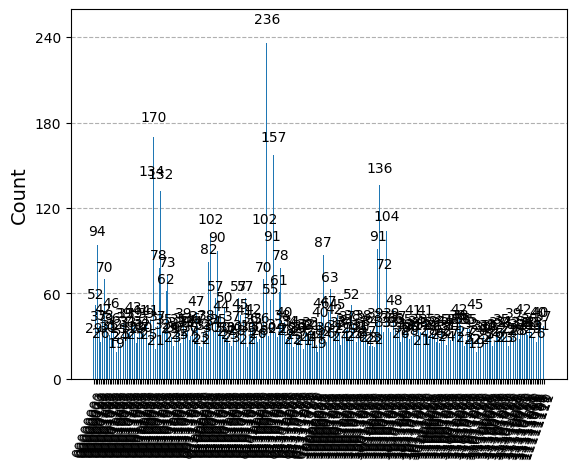

In [15]:
# -----------------------------
# Run
# -----------------------------
backend = Aer.get_backend("aer_simulator")
result = backend.run(qc, shots=shots).result()
counts = result.get_counts()

plot_histogram(counts)


In [16]:
# -----------------------------
# Inspect top results
# -----------------------------
top_k = 10
print(f"\nTop {top_k} measured assignments (decoded):")
for bitstr, cnt in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:top_k]:
    choices = decode_assignment(bitstr, n_ue=N_UE)
    sc = score_assignment(choices, W)
    print(f"count={cnt:5d} | bits={bitstr} | choices={choices} | score(sumW)={sc:.4f}")


Top 10 measured assignments (decoded):
count=  236 | bits=01100010 | choices=['bBS', 'aBS', 'bBS', 'cBS'] | score(sumW)=2.7000
count=  170 | bits=00100010 | choices=['bBS', 'aBS', 'bBS', 'aBS'] | score(sumW)=2.6000
count=  157 | bits=01100110 | choices=['bBS', 'cBS', 'bBS', 'cBS'] | score(sumW)=2.5000
count=  136 | bits=10100010 | choices=['bBS', 'aBS', 'bBS', 'bBS'] | score(sumW)=2.5000
count=  134 | bits=00100001 | choices=['cBS', 'aBS', 'bBS', 'aBS'] | score(sumW)=2.4000
count=  132 | bits=00100110 | choices=['bBS', 'cBS', 'bBS', 'aBS'] | score(sumW)=2.4000
count=  104 | bits=10100110 | choices=['bBS', 'cBS', 'bBS', 'bBS'] | score(sumW)=2.3000
count=  102 | bits=01000010 | choices=['bBS', 'aBS', 'aBS', 'cBS'] | score(sumW)=2.3000
count=  102 | bits=01100001 | choices=['cBS', 'aBS', 'bBS', 'cBS'] | score(sumW)=2.5000
count=   94 | bits=00000010 | choices=['bBS', 'aBS', 'aBS', 'aBS'] | score(sumW)=2.2000


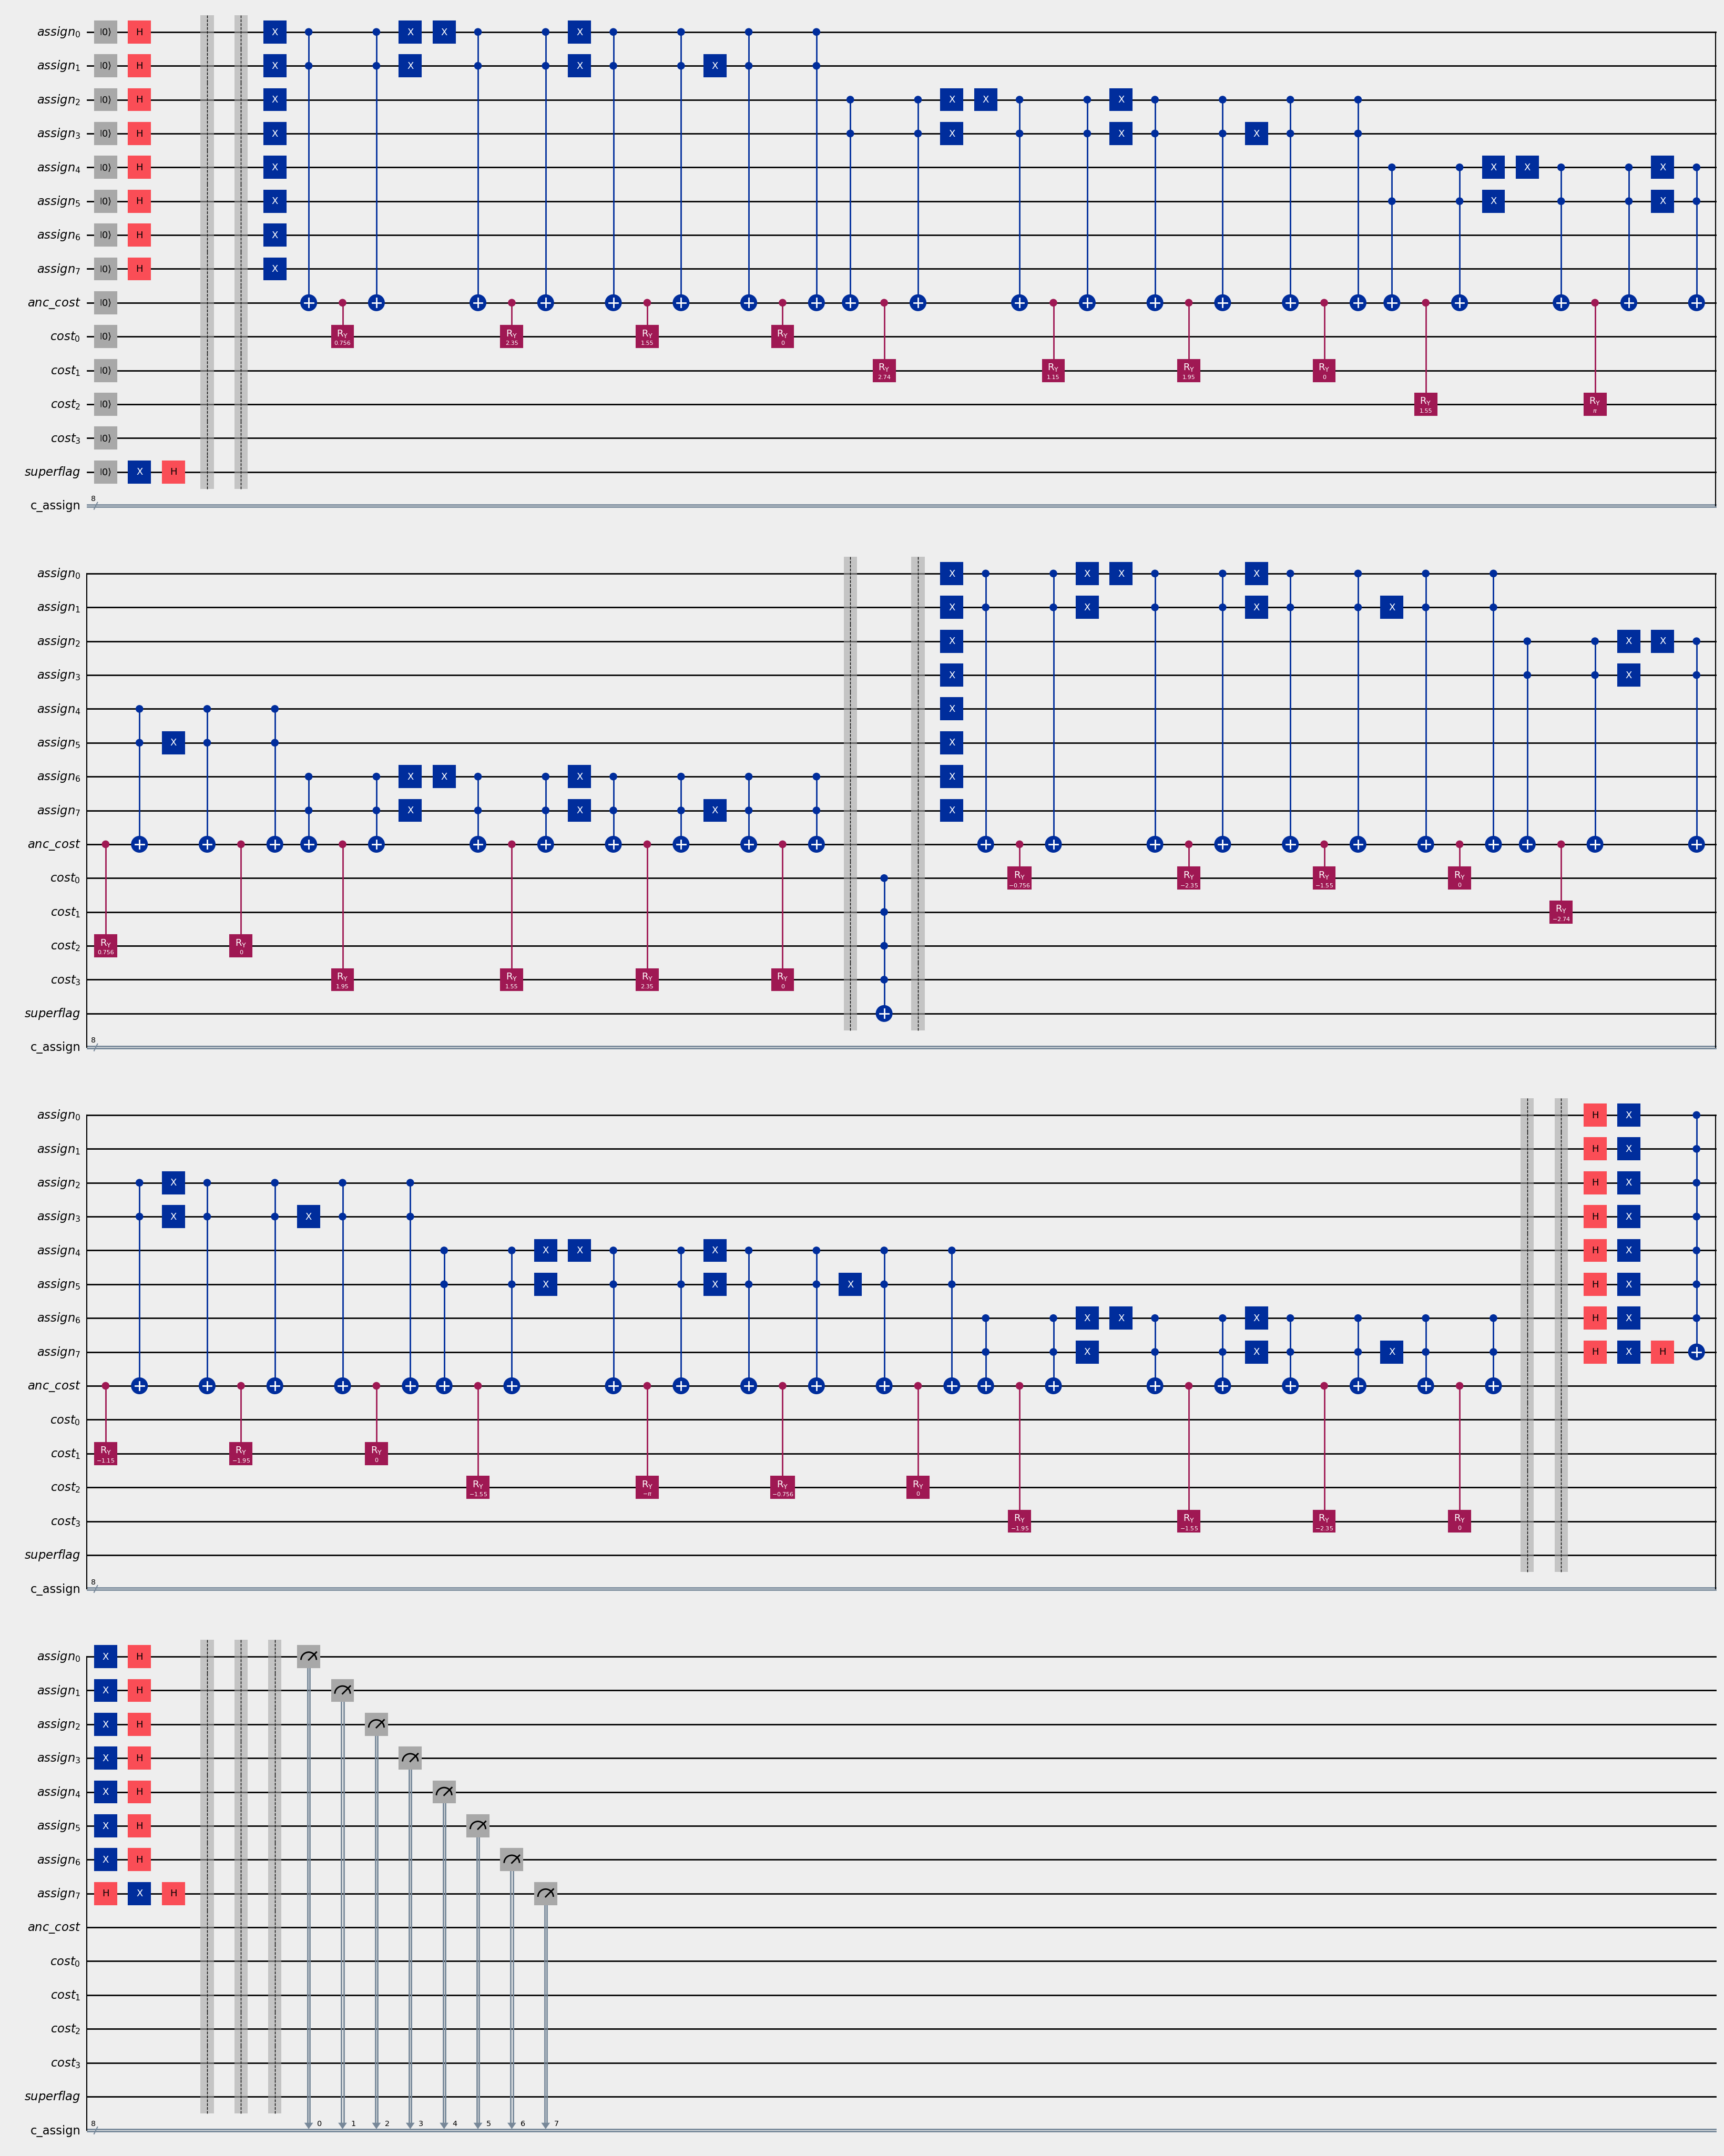

In [17]:
qc.draw(output='mpl',
        scale=1.0,
        fold=48,
        style={'backgroundcolor':'#EEEEEE'},
        plot_barriers=True)